In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn import metrics
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

## LOAD DATA

In [5]:
data = "../data/data_preprocess.csv"
KNN_data = pd.read_csv(data)
print("Data shape:", KNN_data.shape)
print("\nFirst 5 rows:")
print(KNN_data.head(5))

Data shape: (43439, 34)

First 5 rows:
   age  job_level  tenure_years  salary_usd  salary_vs_market_pct  \
0   26          0           5.5       70000                   5.2   
1   35          0           0.5       64000                 -15.5   
2   23          2           2.0      142000                 -15.9   
3   20          4           2.2      147000                   2.6   
4   40          2           6.0      141000                  11.3   

   rto_mandate  days_in_office_required  commute_minutes  prefers_remote  \
0            0                        4               44               1   
1            0                        5               48               1   
2            1                        3               35               1   
3            0                        5               16               0   
4            1                        4               55               1   

   flexibility_importance  ...  department_Data  department_Engineering  \
0             

## CHECK DATA

In [6]:
print("DATA OVERVIEW")
print(f"Total rows: {len(KNN_data)}")
print(f"Total columns: {len(KNN_data.columns)}")
print(f"Missing values:\n{KNN_data.isnull().sum().sum()}")

DATA OVERVIEW
Total rows: 43439
Total columns: 34
Missing values:
0


## CHECK TARGET IMBALANCE

In [7]:
print("TARGET CLASS DISTRIBUTION")
 
print("\nClass counts:")
print(KNN_data['attrition'].value_counts())
 
print("\nClass proportion (%):")
print(KNN_data['attrition'].value_counts(normalize=True) * 100)

TARGET CLASS DISTRIBUTION

Class counts:
attrition
0    35508
1     7931
Name: count, dtype: int64

Class proportion (%):
attrition
0    81.742213
1    18.257787
Name: proportion, dtype: float64


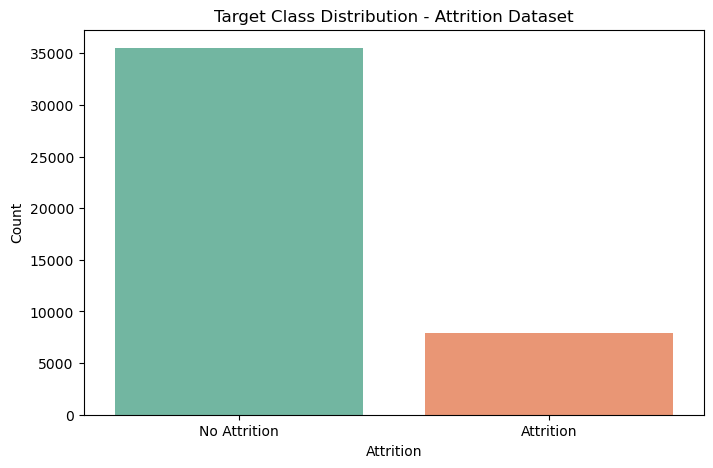

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x=KNN_data['attrition'],
    hue=KNN_data['attrition'],
    palette='Set2',
    legend=False
)

plt.xlabel("Attrition")
plt.ylabel("Count")
plt.title("Target Class Distribution - Attrition Dataset")
plt.xticks([0, 1], ['No Attrition', 'Attrition'])

plt.show()

## SELECT X AND Y

In [9]:
X = KNN_data[[
    'work_arrangement_onsite',
    'days_in_office_required',
    'rto_mandate',
    'burnout_score',
    'commute_minutes',
    'prefers_remote',
    'recent_layoff_round',
    'after_hours_work',
    'job_level',
    'salary_usd',
    'weekly_hours',
]]
 
y = KNN_data['attrition']
 
print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (43439, 11)
Target shape: (43439,)


## TRAIN-TEST SPLIT

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
 
print("TRAIN-TEST SPLIT (Stratified)")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:\n{y_train.value_counts()}")
print(f"\nTest set class distribution:\n{y_test.value_counts()}")

TRAIN-TEST SPLIT (Stratified)
Training set size: 34751
Test set size: 8688

Training set class distribution:
attrition
0    28406
1     6345
Name: count, dtype: int64

Test set class distribution:
attrition
0    7102
1    1586
Name: count, dtype: int64


## EXPERIMENT 1: KNN BASELINE - FIND BEST K

In [11]:
print("EXPERIMENT 1: KNN BASELINE - FIND BEST K")
 
k_values = range(1, 51)
cv_scores = []
 
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
 
for k in k_values:
    knn_model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(
            n_neighbors=k,
            weights='uniform'
        ))
    ])
 
    scores = cross_val_score(
        knn_model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1_macro'
    )
 
    cv_scores.append(scores.mean())
 
best_k = k_values[np.argmax(cv_scores)]
 
print(f"\nBest K: {best_k}")
print(f"Best CV Macro F1: {max(cv_scores):.4f}")

EXPERIMENT 1: KNN BASELINE - FIND BEST K

Best K: 3
Best CV Macro F1: 0.5742


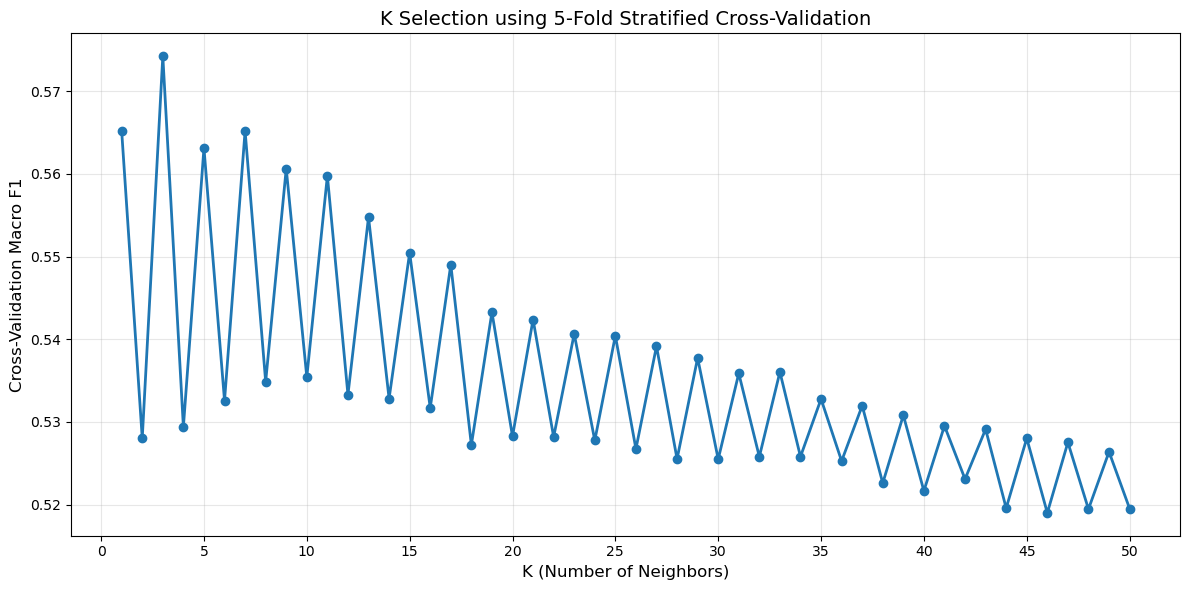

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(k_values, cv_scores, marker='o', linewidth=2, markersize=6)
plt.xlabel("K (Number of Neighbors)", fontsize=12)
plt.ylabel("Cross-Validation Macro F1", fontsize=12)
plt.title("K Selection using 5-Fold Stratified Cross-Validation", fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 51, 5))
plt.tight_layout()
plt.show()

## EXPERIMENT 2: KNN BASELINE - FIND BEST WEIGHT

In [13]:
print("EXPERIMENT 2: KNN BASELINE - FIND BEST WEIGHT")
 
weights_results = []
 
for weight in ['uniform', 'distance']:
    knn_model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(
            n_neighbors=best_k,
            weights=weight
        ))
    ])
 
    scores = cross_val_score(
        knn_model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1_macro'
    )
 
    weights_results.append({
        'Weight': weight,
        'CV_Macro_F1': scores.mean()
    })
 
weights_results_df = pd.DataFrame(weights_results)
print("\nWeights Comparison:")
print(weights_results_df)
 
best_weight = weights_results_df.loc[
    weights_results_df['CV_Macro_F1'].idxmax(),
    'Weight'
]
 
print(f"\nBest K: {best_k}")
print(f"Best Weight: {best_weight}")

EXPERIMENT 2: KNN BASELINE - FIND BEST WEIGHT

Weights Comparison:
     Weight  CV_Macro_F1
0   uniform     0.574239
1  distance     0.574192

Best K: 3
Best Weight: uniform


## EXPERIMENT 3: KNN + SMOTE - FIND BEST K

In [14]:
print("EXPERIMENT 3: KNN + SMOTE - FIND BEST K")
 
k_values_smote = range(1, 51)
cv_scores_smote = []
 
for k in k_values_smote:
    smote_knn = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('knn', KNeighborsClassifier(
            n_neighbors=k,
            weights='uniform'
        ))
    ])
 
    scores = cross_val_score(
        smote_knn,
        X_train,
        y_train,
        cv=cv,
        scoring='f1_macro'
    )
 
    cv_scores_smote.append(scores.mean())
 
best_k_smote = k_values_smote[np.argmax(cv_scores_smote)]
 
print(f"\nBest K (SMOTE): {best_k_smote}")
print(f"Best CV Macro F1 (SMOTE): {max(cv_scores_smote):.4f}")

EXPERIMENT 3: KNN + SMOTE - FIND BEST K

Best K (SMOTE): 48
Best CV Macro F1 (SMOTE): 0.5833


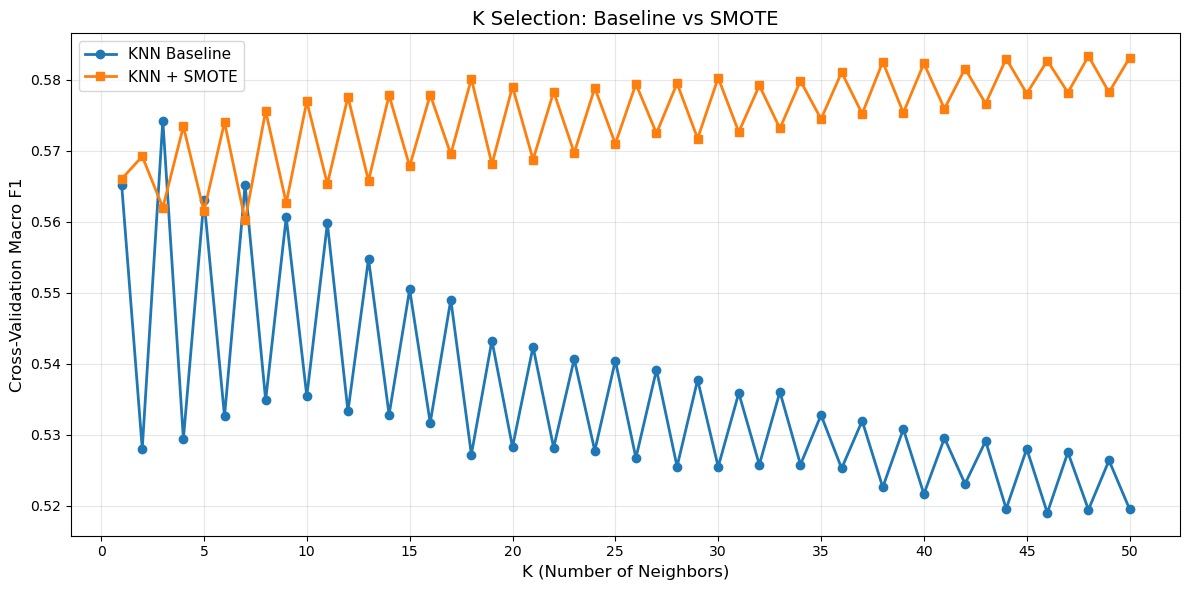

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(k_values, cv_scores, marker='o', label='KNN Baseline', linewidth=2, markersize=6)
plt.plot(k_values_smote, cv_scores_smote, marker='s', label='KNN + SMOTE', linewidth=2, markersize=6)
plt.xlabel("K (Number of Neighbors)", fontsize=12)
plt.ylabel("Cross-Validation Macro F1", fontsize=12)
plt.title("K Selection: Baseline vs SMOTE", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 51, 5))
plt.tight_layout()
plt.show()

## EXPERIMENT 4: KNN + SMOTE - FIND BEST WEIGHT

In [16]:
print("EXPERIMENT 4: KNN + SMOTE - FIND BEST WEIGHT")
 
weights_smote_results = []
 
for weight in ['uniform', 'distance']:
    smote_knn = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('knn', KNeighborsClassifier(
            n_neighbors=best_k_smote,
            weights=weight
        ))
    ])
 
    scores = cross_val_score(
        smote_knn,
        X_train,
        y_train,
        cv=cv,
        scoring='f1_macro'
    )
 
    weights_smote_results.append({
        'Weight': weight,
        'CV_Macro_F1': scores.mean()
    })
 
weights_smote_results_df = pd.DataFrame(weights_smote_results)
print("\nWeights Comparison (SMOTE):")
print(weights_smote_results_df)
 
best_weight_smote = weights_smote_results_df.loc[
    weights_smote_results_df['CV_Macro_F1'].idxmax(),
    'Weight'
]
 
print(f"\nBest K (SMOTE): {best_k_smote}")
print(f"Best Weight (SMOTE): {best_weight_smote}")

EXPERIMENT 4: KNN + SMOTE - FIND BEST WEIGHT

Weights Comparison (SMOTE):
     Weight  CV_Macro_F1
0   uniform     0.583310
1  distance     0.579967

Best K (SMOTE): 48
Best Weight (SMOTE): uniform


## COMPARE ALL EXPERIMENTS

In [17]:
print("COMPARISON: ALL EXPERIMENTS (5-Fold CV Results)")
 
baseline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=best_k,
        weights=best_weight
    ))
])
 
baseline_cv = cross_val_score(
    baseline_knn,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro'
)
 
smote_knn_final = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(
        n_neighbors=best_k_smote,
        weights=best_weight_smote
    ))
])
 
smote_cv = cross_val_score(
    smote_knn_final,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro'
)
 
comparison_results = pd.DataFrame({
    'Model': ['KNN Baseline', 'KNN + SMOTE'],
    'Best_K': [best_k, best_k_smote],
    'Best_Weight': [best_weight, best_weight_smote],
    'CV_Macro_F1_Mean': [baseline_cv.mean(), smote_cv.mean()],
    'CV_Macro_F1_Std': [baseline_cv.std(), smote_cv.std()]
})
 
print("\n" + comparison_results.to_string(index=False))

COMPARISON: ALL EXPERIMENTS (5-Fold CV Results)

       Model  Best_K Best_Weight  CV_Macro_F1_Mean  CV_Macro_F1_Std
KNN Baseline       3     uniform          0.574239         0.008410
 KNN + SMOTE      48     uniform          0.583310         0.004524


## SELECT BEST MODEL

In [18]:
print("SELECT BEST MODEL")
 
if baseline_cv.mean() >= smote_cv.mean():
    best_model_type = 'Baseline'
    best_model_config = {
        'k': best_k,
        'weight': best_weight,
        'smote': False
    }
    final_pipeline = baseline_knn
    print(f"\nSelected: KNN Baseline")
    print(f"  Configuration: K={best_k}, Weight={best_weight}")
    print(f"  CV Macro F1: {baseline_cv.mean():.4f} (±{baseline_cv.std():.4f})")
else:
    best_model_type = 'SMOTE'
    best_model_config = {
        'k': best_k_smote,
        'weight': best_weight_smote,
        'smote': True
    }
    final_pipeline = smote_knn_final
    print(f"\nSelected: KNN + SMOTE")
    print(f"  Configuration: K={best_k_smote}, Weight={best_weight_smote}")
    print(f"  CV Macro F1: {smote_cv.mean():.4f} (±{smote_cv.std():.4f})")

SELECT BEST MODEL

Selected: KNN + SMOTE
  Configuration: K=48, Weight=uniform
  CV Macro F1: 0.5833 (±0.0045)


## FINAL TEST SET EVALUATION

In [16]:
final_pipeline.fit(X_train, y_train)
 
y_pred = final_pipeline.predict(X_test)
y_prob = final_pipeline.predict_proba(X_test)[:, 1]

In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
balanced_acc = balanced_accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
 
print(f"\nTest Set Metrics:")
print(f"  Accuracy:           {accuracy:.4f}")
print(f"  Precision:          {precision:.4f}")
print(f"  Recall:             {recall:.4f}")
print(f"  F1-score:           {f1:.4f}")
print(f"  Macro F1:           {macro_f1:.4f}")
print(f"  Balanced Accuracy:  {balanced_acc:.4f}")
print(f"  ROC-AUC:            {roc_auc:.4f}")


Test Set Metrics:
  Accuracy:           0.6509
  Precision:          0.3023
  Recall:             0.6974
  F1-score:           0.4217
  Macro F1:           0.5859
  Balanced Accuracy:  0.6689
  ROC-AUC:            0.7246


In [18]:
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))

              precision    recall  f1-score   support

No Attrition       0.90      0.64      0.75      7102
   Attrition       0.30      0.70      0.42      1586

    accuracy                           0.65      8688
   macro avg       0.60      0.67      0.59      8688
weighted avg       0.79      0.65      0.69      8688



In [19]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[4549 2553]
 [ 480 1106]]


<Figure size 800x600 with 0 Axes>

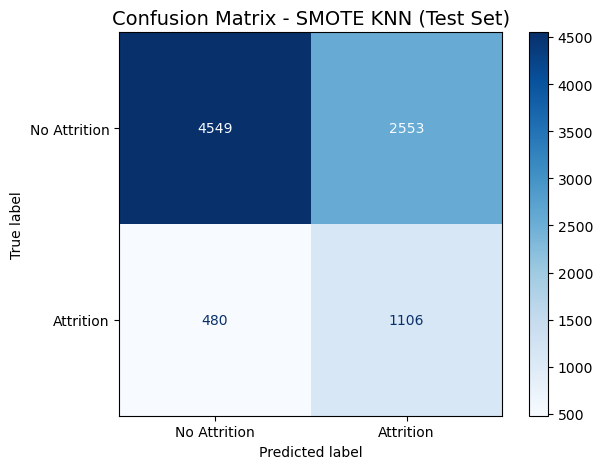

In [20]:
cm_display = metrics.ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=['No Attrition', 'Attrition']
)
 
plt.figure(figsize=(8, 6))
cm_display.plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_type} KNN (Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

## EXPORT RESULTS FOR POWER BI

In [21]:
k_results = pd.DataFrame({
    'K': list(k_values),
    'CV_Macro_F1': cv_scores
})
 
k_results.to_csv('knn_k_selection.csv', index=False)

In [ ]:
k_results_smote = pd.DataFrame({
    'K': list(k_values_smote),
    'CV_Macro_F1_SMOTE': cv_scores_smote
})
 
k_results_smote.to_csv('knn_k_selection_smote.csv', index=False)

In [ ]:
evaluation_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'Macro F1',
        'Balanced Accuracy',
        'ROC-AUC'
    ],
    'Score': [
        accuracy,
        precision,
        recall,
        f1,
        macro_f1,
        balanced_acc,
        roc_auc
    ]
})
 
evaluation_results.to_csv('knn_evaluation.csv', index=False)

In [ ]:
cm_results = pd.DataFrame({
    'Actual': [
        'No Attrition',
        'No Attrition',
        'Attrition',
        'Attrition'
    ],
    'Predicted': [
        'No Attrition',
        'Attrition',
        'No Attrition',
        'Attrition'
    ],
    'Count': [
        conf_matrix[0, 0],
        conf_matrix[0, 1],
        conf_matrix[1, 0],
        conf_matrix[1, 1]
    ]
})
 
cm_results.to_csv('knn_confusion_matrix.csv', index=False)

In [ ]:
summary_results = pd.DataFrame({
    'Model_Type': [best_model_type],
    'Best_K': [best_model_config['k']],
    'Best_Weight': [best_model_config['weight']],
    'SMOTE_Used': [best_model_config['smote']],
    'CV_Macro_F1': [baseline_cv.mean() if best_model_type == 'Baseline' else smote_cv.mean()],
    'Test_Accuracy': [round(accuracy * 100, 2)],
    'Test_Macro_F1': [round(macro_f1 * 100, 2)],
    'Test_ROC_AUC': [round(roc_auc * 100, 2)]
})
 
summary_results.to_csv('knn_summary.csv', index=False)

In [ ]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)
 
performance_results = pd.DataFrame({
    'Class': [
        'No Attrition',
        'Attrition'
    ],
    'Precision': [
        report['0']['precision'],
        report['1']['precision']
    ],
    'Recall': [
        report['0']['recall'],
        report['1']['recall']
    ],
    'F1-score': [
        report['0']['f1-score'],
        report['1']['f1-score']
    ],
    'Support': [
        int(report['0']['support']),
        int(report['1']['support'])
    ]
})
 
performance_results.to_csv('knn_performance.csv', index=False)

In [ ]:
comparison_results.to_csv('knn_experiments_comparison.csv', index=False)

In [ ]:
k_comparison = pd.DataFrame({
    'K': list(k_values),
    'KNN Baseline': cv_scores,
    'KNN + SMOTE': cv_scores_smote
})

k_comparison.to_csv('knn_k_comparison.csv',index=False)

In [29]:
weight_comparison = pd.DataFrame({
    'Configuration': [
        'Baseline - Uniform',
        'Baseline - Distance',
        'SMOTE - Uniform',
        'SMOTE - Distance'
    ],
    'CV_Macro_F1': [
        weights_results_df.loc[
            weights_results_df['Weight'] == 'uniform',
            'CV_Macro_F1'
        ].iloc[0],

        weights_results_df.loc[
            weights_results_df['Weight'] == 'distance',
            'CV_Macro_F1'
        ].iloc[0],

        weights_smote_results_df.loc[
            weights_smote_results_df['Weight'] == 'uniform',
            'CV_Macro_F1'
        ].iloc[0],

        weights_smote_results_df.loc[
            weights_smote_results_df['Weight'] == 'distance',
            'CV_Macro_F1'
        ].iloc[0]
    ]
})

weight_comparison.to_csv('knn_weight_comparison.csv',index=False)